# 01 - Analisi Dati
## Obiettivo del notebook
Capire la struttura generale del dataset e produrre una prima analisi esplorativa

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#1. Caricamento dati
In questa fase iniziale, procediamo all'importazione dei file sorgente in formato .csv. Carichiamo il set di addestramento (train_values), le relative etichette di target (train_labels) e il dataset dedicato alla validazione finale (test_values)

In [2]:
train_values = pd.read_csv('../data/raw/train_values.csv')
train_labels = pd.read_csv('../data/raw/train_labels.csv')
test_values = pd.read_csv('../data/raw/test_values.csv')

#2. Unione train values e train labels
Per facilitare l'analisi esplorativa e la visualizzazione, effettuiamo un merge tra le caratteristiche delle strutture e i gradi di danno corrispondenti. Utilizziamo la colonna *building_id* come chiave primaria per garantire che ogni edificio sia correttamente associato al proprio target

In [3]:
df = train_values.merge(train_labels, on='building_id')
df.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3


#3. Analisi dello shape e info
Prima di procedere con l'analisi statistica, verifichiamo i valori del dataset:

* **Shape**: Controllo delle dimensioni (righe e colonne).

* **Missing Values**: Identificazione di eventuali valori nulli che richiederebbero tecniche di imputation.

* **Info**: Panoramica dei tipi di dato presenti (Dtype) per individuare discrepanze tecniche.

## Training set

In [4]:
print(f"Training set shape: {df.shape}")
print(f"Total null values in Training set: {df.isnull().sum().sum()}")
df.info()

Training set shape: (260601, 40)
Total null values in Training set: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 40 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   building_id                             260601 non-null  int64 
 1   geo_level_1_id                          260601 non-null  int64 
 2   geo_level_2_id                          260601 non-null  int64 
 3   geo_level_3_id                          260601 non-null  int64 
 4   count_floors_pre_eq                     260601 non-null  int64 
 5   age                                     260601 non-null  int64 
 6   area_percentage                         260601 non-null  int64 
 7   height_percentage                       260601 non-null  int64 
 8   land_surface_condition                  260601 non-null  object
 9   foundation_type                         260601 non-null

## Test set

In [7]:
print(f"Test set shape: {test_values.shape}")
print(f"Total null values in Test set: {test_values.isnull().sum().sum()}")
test_values.info()

Test set shape: (86868, 39)
Total null values in Test set: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86868 entries, 0 to 86867
Data columns (total 39 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   building_id                             86868 non-null  int64 
 1   geo_level_1_id                          86868 non-null  int64 
 2   geo_level_2_id                          86868 non-null  int64 
 3   geo_level_3_id                          86868 non-null  int64 
 4   count_floors_pre_eq                     86868 non-null  int64 
 5   age                                     86868 non-null  int64 
 6   area_percentage                         86868 non-null  int64 
 7   height_percentage                       86868 non-null  int64 
 8   land_surface_condition                  86868 non-null  object
 9   foundation_type                         86868 non-null  object
 10  roof_type

#4. Distinzione tra feature categoriche e numeriche
Le variabili all'interno del dataset non sono tutte uguali. In questa sezione le dividiamo in:

* **Categoriche**: Variabili descrittive (es. materiali, destinazione d'uso)

* **Numeriche**: Variabili quantitative (es. numero di piani, altezza)

In [6]:
# Escludiamo 'building_id' (identifier) and 'damage_grade' (target)
features = df.drop(columns=['building_id', 'damage_grade'])

categorical_cols = features.select_dtypes(include=['object']).columns.tolist()
numeric_cols = features.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Note: geo_level_ids are technically integers but conceptually categorical
print(f"Categorical features: {categorical_cols}")
print(f"Numerical features: {numeric_cols}")

Categorical features: ['land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'legal_ownership_status']
Numerical features: ['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id', 'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone', 'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick', 'has_superstructure_timber', 'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered', 'has_superstructure_other', 'count_families', 'has_secondary_use', 'has_secondary_use_agriculture', 'has_secondary_use_hotel', 'has_secondary_use_rental', 'has_secondary_use_institution', 'has_secondary_use_school', 'has_secondary_use_industry', 'has_secondary_use_health_post', 'has_secondary_use_gov_office', '

Nota: le features *geo_level_ids* sono numeri interi ma in realtà rappresentano categorie

#5. Distribuzione del *damage_grade* (target)
Analizziamo lo sbilanciamento delle classi nel *damage_grade*. Capire se il dataset è equilibrato o se una categoria di danno (es. "Grado 2") è predominante è fondamentale per scegliere correttamente le metriche di valutazione del modello

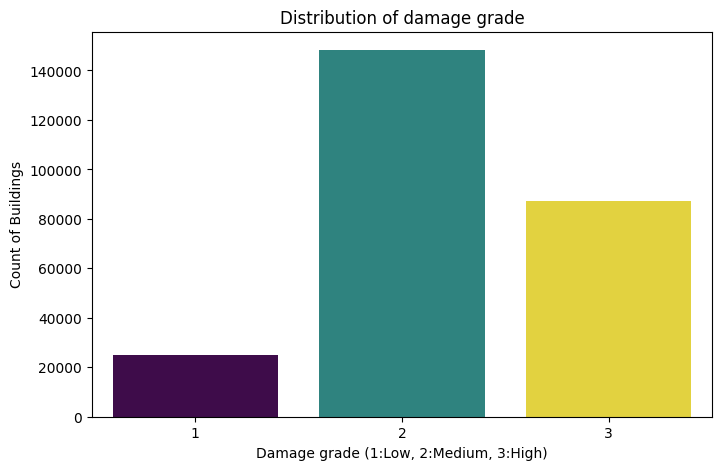


Percentage distribution of damage grade:
damage_grade
1     9.640792
2    56.891186
3    33.468022
Name: proportion, dtype: float64


In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(x='damage_grade', data=df, hue='damage_grade', palette='viridis', legend=False)
plt.title('Distribution of damage grade')
plt.xlabel('Damage grade (1:Low, 2:Medium, 3:High)')
plt.ylabel('Count of Buildings')
plt.show()

# Print percentage distribution
print("\nPercentage distribution of damage grade:")
print(df['damage_grade'].value_counts(normalize=True).sort_index() * 100)

#6. Visualizzazione delle feature chiave
## *Building age* vs *damage grade*
Attraverso l'uso di **Boxplot**, esploriamo la relazione tra l'anzianità degli edifici e la gravità del danno subito. L'obiettivo è verificare se le costruzioni più datate presentano una vulnerabilità strutturale significativamente maggiore rispetto a quelle recenti

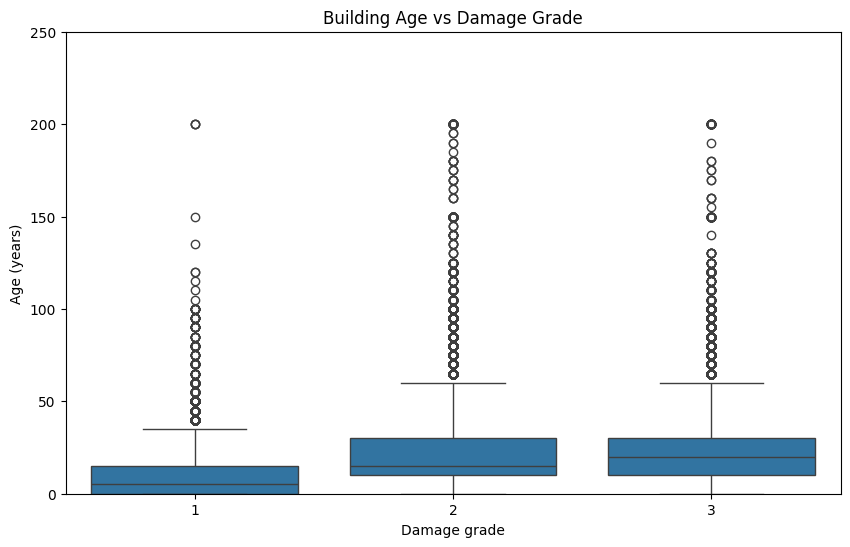

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='damage_grade', y='age', data=df)
plt.title("Building Age vs Damage Grade")
plt.xlabel('Damage grade')
plt.ylabel('Age (years)')
plt.ylim(0, 250)
plt.show()

#7. Analisi del materiale delle strutture
## Mud mortar - stone
Iniziamo un'analisi specifica sulle tecniche costruttive. In particolare, ci concentriamo sulla malta di fango e pietra (mud mortar - stone), una tecnica tradizionale spesso associata a un'alta vulnerabilità sismica. Visualizziamo come la presenza di questo materiale influenzi la distribuzione dei gradi di danno

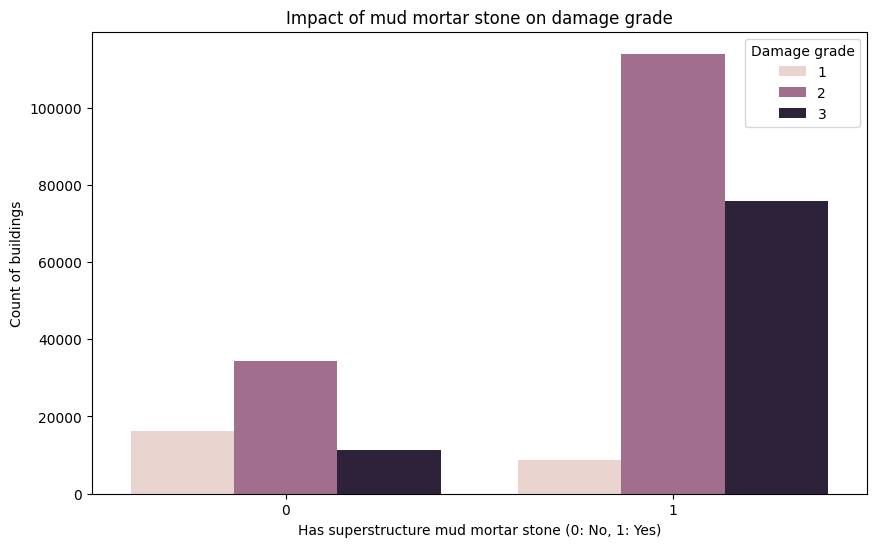

In [10]:
plt.figure(figsize=(10, 6))
sns.countplot(x='has_superstructure_mud_mortar_stone', hue='damage_grade', data=df)
plt.title('Impact of mud mortar stone on damage grade')
plt.xlabel('Has superstructure mud mortar stone (0: No, 1: Yes)')
plt.ylabel('Count of buildings')
plt.legend(title='Damage grade')
plt.show()